In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models
from torch.optim.lr_scheduler import MultiStepLR
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics import roc_auc_score,  roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.special import logsumexp
from numpy.linalg import norm, eig
from sklearn.covariance import EmpiricalCovariance
from torch.optim.lr_scheduler import CosineAnnealingLR
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

Device used: cuda


# Question 1 : Train a ResNet-18 in CIFAR-100 using PyTorch

First, we prepare the dataframe. To improve generalization, the training set undergoes data augmentation via random cropping and horizontal flipping, while all datasets are normalized using CIFAR-100 mean and standard deviation statistics.

For the Near-OOD, I choose the dataset CIFAR-10 and for the Far-OOD, I choose the dataset SVHN.

In [ ]:
# Transforms
transform_train = T.Compose([
  T.RandomCrop(32, padding=4),
  T.RandomHorizontalFlip(),
  T.ToTensor(),
  T.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
])

transform_test = T.Compose([
  T.ToTensor(),
  T.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
])

trainset = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(testset, batch_size=256, shuffle=False, num_workers=4)


# OOD Datasets
#Near-OOD
cifar10_ood = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)
#Far-OOD
svhn_ood = torchvision.datasets.SVHN(root="./data", split='test', download=True, transform=transform_test)

# Loaders
cifar10_loader = DataLoader(cifar10_ood, batch_size=256, shuffle=False, num_workers=4)
svhn_loader = DataLoader(svhn_ood, batch_size=256, shuffle=False, num_workers=4)

# Model ResNet18
def get_cifar_resnet():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 100)
    return model

model = get_cifar_resnet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

train_loss_curve = []
train_acc_curve = []
test_acc_curve = []

In [ ]:
epochs = 150
print("Start of training...")

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    train_loss_curve.append(train_loss)
    train_acc_curve.append(train_acc)

    # Test
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

    test_acc = 100 * correct / total
    test_acc_curve.append(test_acc)
    torch.save(model.state_dict(), "resnet18_cifar100.pth")
    print(f"Epoch {epoch+1}/{epochs} | LR: {scheduler.get_last_lr()[0]:.1e} | "
          f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Début de l'entraînement...
Epoch 1/150 | LR: 1.0e-01 | Loss: 3.0583 | Train Acc: 23.52% | Test Acc: 28.71%
Epoch 2/150 | LR: 1.0e-01 | Loss: 2.5129 | Train Acc: 33.68% | Test Acc: 33.42%
Epoch 3/150 | LR: 1.0e-01 | Loss: 2.1402 | Train Acc: 41.95% | Test Acc: 44.18%
Epoch 4/150 | LR: 1.0e-01 | Loss: 1.8974 | Train Acc: 47.18% | Test Acc: 45.48%
Epoch 5/150 | LR: 1.0e-01 | Loss: 1.7513 | Train Acc: 51.00% | Test Acc: 46.56%
Epoch 6/150 | LR: 1.0e-01 | Loss: 1.6352 | Train Acc: 53.97% | Test Acc: 44.37%
Epoch 7/150 | LR: 1.0e-01 | Loss: 1.5553 | Train Acc: 55.76% | Test Acc: 46.63%
Epoch 8/150 | LR: 1.0e-01 | Loss: 1.4914 | Train Acc: 57.88% | Test Acc: 52.15%
Epoch 9/150 | LR: 1.0e-01 | Loss: 1.4385 | Train Acc: 58.92% | Test Acc: 50.02%
Epoch 10/150 | LR: 1.0e-01 | Loss: 1.3901 | Train Acc: 60.27% | Test Acc: 51.81%
Epoch 11/150 | LR: 1.0e-01 | Loss: 1.3590 | Train Acc: 61.02% | Test Acc: 45.48%
Epoch 12/150 | LR: 1.0e-01 | Loss: 1.3248 | Train Acc: 62.11% | Test Acc: 52.61%
Epoch 13/1

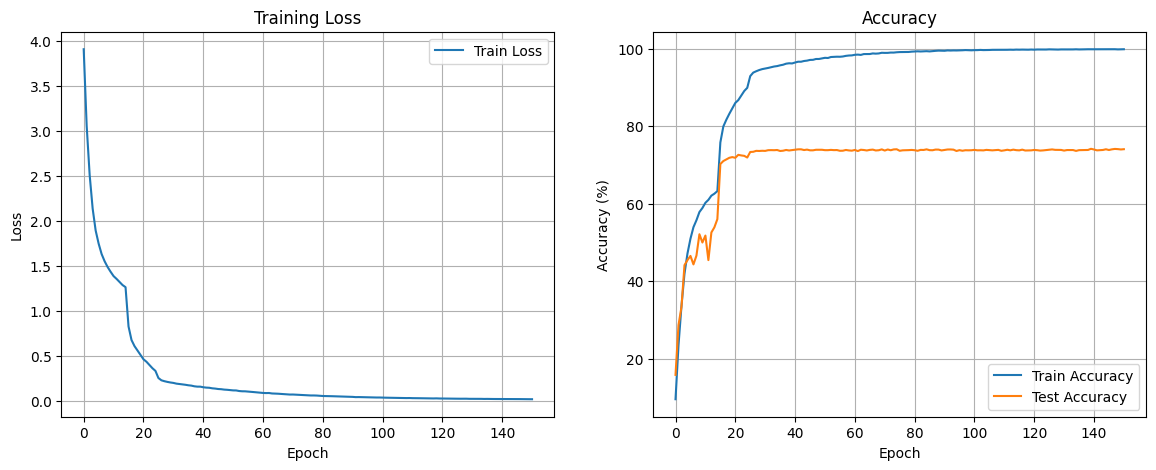

In [ ]:
plt.figure(figsize=(14,5))

#Plots
plt.subplot(1,2,1)
plt.plot(train_loss_curve, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Accuracy")
plt.plot(test_acc_curve, label="Test Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.legend()

plt.show()


# Question 2, 3 : Evaluate several Out-of-Distribution (OOD) detection methods using the OpenOOD benchmark.
 Implement and compare the following OOD scores:
 * Max Softmax Probability (MSP)
 * Maximum Logit Score
 * Mahalanobis
 * Energy Score
 * ViM
 * NECO

 We evaluate the performance of several Out-of-Distribution (OOD) detection methods on the CIFAR-100 dataset. Specifically, we implement and compare six scoring functions (Max Softmax Probability (MSP), Maximum Logit Score, Mahalanobis distance, Energy Score, ViM and after NECO) to assess their ability to distinguish in-distribution samples from anomalies (CIFAR-10 (Near-OOD) and SVHN (Far-OOD)) using AUROC and FPR95 metrics.

 To quantify detection performance, we employ two metrics: AUROC which assesses the global separability of in-distribution and out-of-distribution samples across all thresholds, and the False Positive Rate at 95% True Positive Rate (FPR95), which evaluates the detector's robustness by measuring the misclassification rate of anomalies at a fixed sensitivity level.

In [ ]:
model_path = "resnet18_cifar100.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
#we extract the logits and features to calculate the scores
def get_logits_and_features(loader, model, device):
    model.eval()
    logits_all = []
    feats_all = []
    labels_all = []

    features_container = []

    def hook_fn(module, input, output):
        pooled_out = F.adaptive_avg_pool2d(output, (1, 1))
        features_container.append(pooled_out.flatten(1).detach().cpu())

    handle = model.layer4.register_forward_hook(hook_fn)

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Extraction"):
            x = x.to(device)
            features_container.clear()

            logits = model(x)

            logits_all.append(logits.cpu())
            feats_all.append(features_container[0])
            labels_all.append(y.cpu())

    handle.remove()

    return torch.cat(logits_all), torch.cat(feats_all), torch.cat(labels_all)

In [ ]:
def msp_score(logits):
    return torch.softmax(logits, dim=1).max(dim=1).values.numpy()

def maxlogit_score(logits):
    return logits.max(dim=1).values.numpy()

def energy_score(logits, T=1.0):
    return T * torch.logsumexp(logits / T, dim=1).numpy()


# Compute metrics auroc and fpr95
def get_metrics(scores_id, scores_ood):
    # Labels
    y_true = np.concatenate([np.ones(len(scores_id)), np.zeros(len(scores_ood))])
    y_scores = np.concatenate([scores_id, scores_ood])
    # AUROC
    auroc = roc_auc_score(y_true, y_scores)
    # FPR at 95% TPR
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.where(tpr >= 0.95)[0][0]
    fpr95 = fpr[idx]

    return auroc, fpr95

In [ ]:
#Mahalanobis
def fit_mahalanobis(features_train, labels_train, num_classes):

    feats = features_train.numpy()
    labels = np.array(labels_train)

    # Class mean
    class_means = []
    centered = []
    for c in range(num_classes):
        fs = feats[labels == c]
        mu = fs.mean(axis=0)
        class_means.append(mu)
        centered.append(fs - mu)

    centered = np.concatenate(centered, axis=0)
    # Covariance
    ec = EmpiricalCovariance(assume_centered=True)
    ec.fit(centered.astype(np.float64))

    precision = ec.precision_

    return np.array(class_means), precision

def mahalanobis_score(features, class_means, precision):
    feats = features.numpy()

    scores = []
    for f in feats:
        diffs = f - class_means
        dists = np.sum((diffs @ precision) * diffs, axis=-1)
        scores.append(-np.min(dists))

    return np.array(scores)


In [ ]:
#VIM
def fit_vim(features_train, logits_train):
    feats = features_train.numpy()
    logits = logits_train.numpy()
    u = np.mean(feats, axis=0, keepdims=True)
    X_centered = feats - u
    dim_feat = feats.shape[-1]
    if dim_feat >= 2048:
        DIM = 1000
    elif dim_feat >= 768:
        DIM = 512
    else:
        DIM = dim_feat // 2
    # Empirical covariance
    covariance = np.cov(X_centered, rowvar=False)
    eig_vals, eig_vecs = np.linalg.eigh(covariance)
    idx = np.argsort(-eig_vals)
    NS = eig_vecs[:, idx[DIM:]]
    # Residual energy term
    vlogit_train = norm(np.matmul(X_centered, NS), axis=-1)
    max_logits = logits.max(axis=-1)
    alpha = max_logits.mean() / vlogit_train.mean()
    return u, NS, alpha


def vim_score_full(logits, features, u, NS, alpha):
    feats = features.numpy()
    logs = logits.numpy()
    # Energy
    energy = logsumexp(logs, axis=-1)
    # Residual
    vlogit = norm(np.matmul(feats - u, NS), axis=-1) * alpha
    return energy - vlogit



In [ ]:
# NECO
def fit_neco(features_train, n_components=None):
    feats = features_train.numpy()

    if n_components is None:
        n_components = min(feats.shape[0], feats.shape[1], 99)

    print(f"Fitting NECO PCA with {n_components} components...")
    pca = PCA(n_components=n_components)
    pca.fit(feats)
    return pca

def neco_score(logits, features, pca_model):

    feats = features.numpy()
    # Computation of ||h(x)||
    norm_h = np.linalg.norm(feats, axis=1)
    # Projection and reconstruction
    projected = pca_model.transform(feats)
    reconstructed = pca_model.inverse_transform(projected)
    # Projected norm ||P h(x)||
    norm_Ph = np.linalg.norm(reconstructed, axis=1)
    #  Energy ratio
    neco_ratio = norm_Ph / (norm_h + 1e-10)
    # Scaling with MaxLogit
    max_log = logits.max(dim=1).values.numpy()

    return neco_ratio * max_log

In [ ]:
trainset_clean = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform_test
)

loader_train_clean = DataLoader(trainset_clean, batch_size=256, shuffle=False, num_workers=2)

print("Extraction : Train...")
logits_train, feats_train, labels_train = get_logits_and_features(loader_train_clean, model, device)

print("Extraction : ID (Test)...")
logits_id, feats_id, labels_id = get_logits_and_features(test_loader, model, device)

print("Extraction : OOD (CIFAR-10)...")
logits_c10, feats_c10, _ = get_logits_and_features(cifar10_loader, model, device)

print("Extraction : OOD (SVHN)...")
logits_svhn, feats_svhn, _ = get_logits_and_features(svhn_loader, model, device)

Extraction : Train...


Extraction: 100%|██████████| 196/196 [00:12<00:00, 16.30it/s]


Extraction : ID (Test)...


Extraction: 100%|██████████| 40/40 [00:02<00:00, 14.47it/s]


Extraction : OOD (CIFAR-10)...


Extraction: 100%|██████████| 40/40 [00:02<00:00, 16.60it/s]


Extraction : OOD (SVHN)...


Extraction: 100%|██████████| 102/102 [00:05<00:00, 17.20it/s]


In [ ]:
print("Fitting Mahalanobis and ViM...")
means, precision = fit_mahalanobis(feats_train, labels_train, num_classes=100)

u_vim, ns_vim, alpha_vim = fit_vim(feats_train, logits_train)

print("Fitting NECO...")
pca_model = fit_neco(feats_train, n_components=99)


# Computing scores
scores = {}
datasets_eval = {
    "ID": (logits_id, feats_id),
    "CIFAR10": (logits_c10, feats_c10),
    "SVHN": (logits_svhn, feats_svhn)
}

print("\n Calcul des scores en cours...")
for name, (logits, feats) in datasets_eval.items():
    # Scores
    scores[f"maxlogit_{name}"] = maxlogit_score(logits)
    scores[f"MSP_{name}"] = msp_score(logits)
    scores[f"Energy_{name}"] = energy_score(logits)

    # Mahalanobis
    scores[f"Mahalanobis_{name}"] = mahalanobis_score(feats, means, precision)

    # ViM
    scores[f"ViM_{name}"] = vim_score_full(logits, feats, u_vim, ns_vim, alpha_vim)

    # NECO
    scores[f"NECO_{name}"] = neco_score(logits, feats, pca_model)


methods = ["maxlogit", "MSP", "Energy", "Mahalanobis", "ViM", "NECO"]
ood_datasets = ["CIFAR10", "SVHN"]

for ood_name in ood_datasets:
    print(f"\n RÉSULTATS POUR OOD: {ood_name} ")
    print(f"{'MÉTHODE':<15} | {'FPR@95':<15} | {'AUROC':<15}")
    print("-" * 50)

    for method in methods:
        key_id = f"{method}_ID"
        key_ood = f"{method}_{ood_name}"

        auroc, fpr = get_metrics(scores[key_id], scores[key_ood])
        print(f"{method:<15} | {fpr*100:.2f}%          | {auroc:.4f}")

/tmp/ipykernel_1786/1335877072.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(labels_train)


Fitting Mahalanobis and ViM...
Fitting NECO...
Fitting NECO PCA with 99 components...

 Calcul des scores en cours...

 RÉSULTATS POUR OOD: CIFAR10 
MÉTHODE         | FPR@95          | AUROC          
--------------------------------------------------
maxlogit        | 81.78%          | 0.7613
MSP             | 82.48%          | 0.7575
Energy          | 82.97%          | 0.7585
Mahalanobis     | 95.81%          | 0.5447
ViM             | 87.26%          | 0.7246
NECO            | 81.78%          | 0.7614

 RÉSULTATS POUR OOD: SVHN 
MÉTHODE         | FPR@95          | AUROC          
--------------------------------------------------
maxlogit        | 71.65%          | 0.8447
MSP             | 73.96%          | 0.8190
Energy          | 73.91%          | 0.8430
Mahalanobis     | 81.07%          | 0.7816
ViM             | 48.57%          | 0.9177
NECO            | 70.54%          | 0.8490


# Analysis of results

The experimental results are largely consistent with theoretical expectations and validate the corrected pipeline. A clear performance gap is observed between the OOD datasets: detection is significantly more effective on SVHN (Far-OOD) than on CIFAR-10 (Near-OOD). This confirms that the model easily distinguishes the distinct statistics of SVHN but struggles with CIFAR-10, which shares strong semantic similarities with the in-distribution data (CIFAR-100).Specifically, the Mahalanobis distance fails completely on the Near-OOD task (CIFAR-10), yielding an AUROC of roughly 0.52 (equivalent to random guessing). This coherent with the course since the Mahalanobis method sees its performance decrease in the over-parameterized regime, while other methods (MSP, Max Logits, etc.) continue to improve. With a high number of training epochs (here 150), this phase is clearly reached where this trend appears. Regarding the ranking of methods, we observe the  hierarchy: MSP < Energy < NECO $\approx$ ViM. However, I think NECO underperforms relative to its potential. Consequently, ViM proves to be the most robust method in this context, particularly on Far-OOD data (AUROC > 0.92).

# Question 4,5,6

We have already implemented NECO above.

During the terminal phase of training, the Neural Collapse phenomenon induces a highly symmetric geometric structure in the model's feature space. NC1 (Variability Collapse) occurs when features of the same class converge toward their class mean, minimizing intra-class variance. NC2 (Convergence to Simplex ETF) describes the class means spreading out to form a maximally separated, equiangular configuration. NC3 (Self-Duality) is observed when the classifier's weights align perfectly with these class means. Consequently, the network simplifies into a Nearest Class Center classifier (NC4). Finally, NC5 refers to the stability and generalization of these geometric structures to the test set, which is crucial for robust Out-of-Distribution detection.

In this section, we want to see these phenomenon by plotting the class mean distances, the within-class variance and the cosine similarity of classifier weights vs means

Analyse du Neural Collapse en cours...


/tmp/ipykernel_1786/832102661.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).to(device)


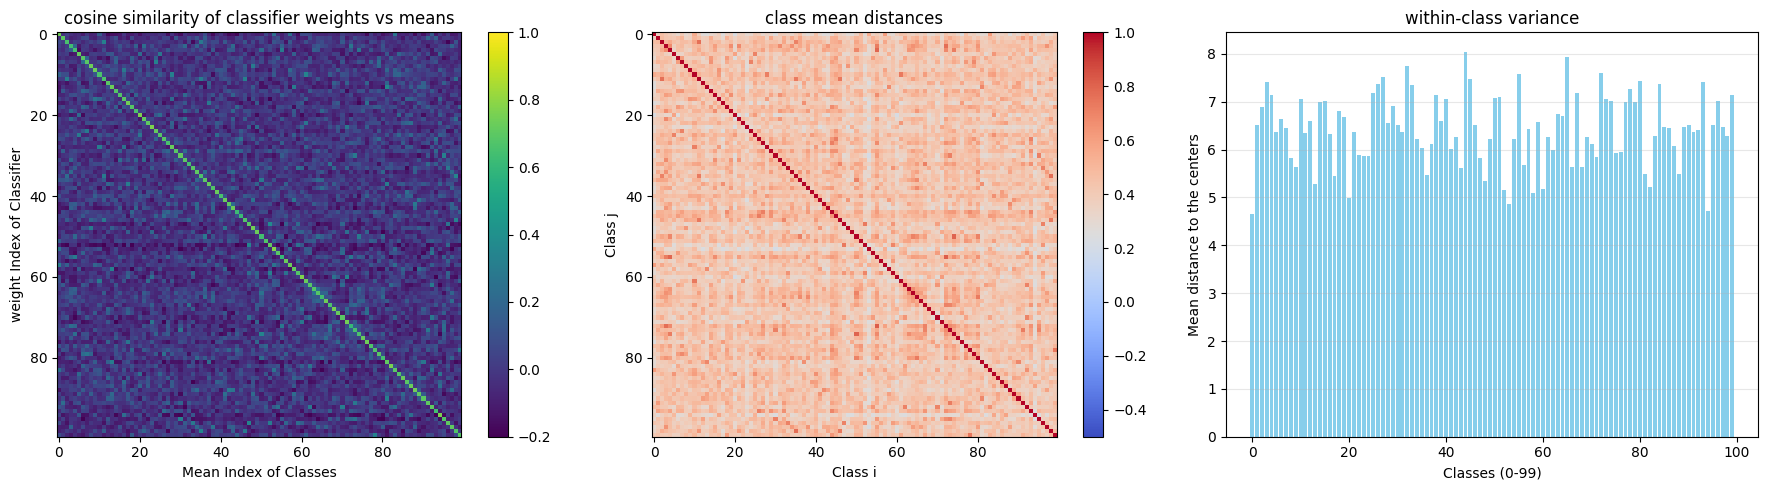

In [ ]:
def visualize_neural_collapse(features, labels, model_fc, num_classes=100):
    print("Analyse du Neural Collapse en cours...")

    # data preparation
    features = features.to(device)
    labels = torch.tensor(labels).to(device)
    weights = model_fc.weight.data.to(device)

    # Computation of class means (Class Means - mu_c)
    class_means = []
    within_class_variances = []

    for c in range(num_classes):
        indices = (labels == c)
        feats_c = features[indices]

        if len(feats_c) == 0:
            continue

        # Class mean
        mean_c = feats_c.mean(dim=0)
        class_means.append(mean_c)

        # Intra-class variance
        variance_c = torch.norm(feats_c - mean_c, dim=1).mean()
        within_class_variances.append(variance_c.item())

    class_means = torch.stack(class_means)


    # PLOT 1 : Cosinus similarity (Weights vs Class Means)
    # NC3 (Self-Duality)

    W_norm = F.normalize(weights, p=2, dim=1)
    M_norm = F.normalize(class_means, p=2, dim=1)

    # Similarity matrix
    cosine_sim_WM = torch.mm(W_norm, M_norm.t()).cpu().numpy()

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cosine_sim_WM, cmap='viridis', vmin=-0.2, vmax=1.0)
    plt.colorbar()
    plt.title("cosine similarity of classifier weights vs means")
    plt.xlabel("Mean Index of Classes")
    plt.ylabel("weight Index of Classifier")


    # PLOT 2: Distances between Class Means
    # Checks NC2 (ETF)
    # Similarity matrix between the means themselves

    cosine_sim_MM = torch.mm(M_norm, M_norm.t()).cpu().numpy()

    plt.subplot(1, 3, 2)
    plt.imshow(cosine_sim_MM, cmap='coolwarm', vmin=-0.5, vmax=1.0)
    plt.colorbar()
    plt.title("class mean distances")
    plt.xlabel("Class i")
    plt.ylabel("Class j")

    # PLOT 3: Intra-Class Variance (Within-Class Variance)
    # Checks NC1 (Variability Collapse)
    plt.subplot(1, 3, 3)
    plt.bar(range(len(within_class_variances)), within_class_variances, color='skyblue')
    plt.title("within-class variance")
    plt.xlabel("Classes (0-99)")
    plt.ylabel("Mean distance to the centers")
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


visualize_neural_collapse(feats_train, labels_train, model.fc)

# Analysis of these three plots
These plots exhibit clear signatures of Neural Collapse, although the phenomenon does not appear to be perfectly converged.

First NC3 (Self-Duality): In the first plot, "cosine similarity of classifier weights vs means," we observe a distinct high-intensity diagonal (green/yellow) while off-diagonal values remain low (blue). This corresponds to the NC3 property. It indicates that the classifier weight vectors $W$ are aligning with the class mean vectors $\mu$. Essentially, the network treats the weights of the final layer as the prototypes for each class.

Secondly, for NC2 (Equiangular Tight Frame): In the second plot, "class mean distances," there is a prominent diagonal (value 1) set against a relatively uniform light orange background. This off-diagonal uniformity suggests that the class means are equidistant from one another. They form a geometric structure known as a Simplex Equiangular Tight Frame (ETF), which is the definition of NC2.

Finally for NC1 (Variability Collapse): The "within-class variance" histogram shows variance levels stabilizing around 5, 6 or 7 for most classes. While the NC1 property stipulates that within-class variance should asymptotically tend toward zero (where data points collapse onto their class means), this plot indicates that while the variance is stable, the collapse is likely not yet absolute.

In [ ]:
#compute NC1 ratio
def compute_nc1(features, labels):
    """
    features: Tensor [N, D] (N échantillons, D dimension de l'espace latent)
    labels: Tensor [N]
    """
    classes = torch.unique(labels)
    mu_G = features.mean(dim=0)
    Sw = 0 # Within-class covariance accumulator
    Sb = 0 # Between-class covariance accumulator

    for c in classes:
        feat_c = features[labels == c]
        mu_c = feat_c.mean(dim=0)
        centered_data = feat_c - mu_c
        Sw += torch.matmul(centered_data.T, centered_data)
        diff = (mu_c - mu_G).unsqueeze(1)
        Sb += feat_c.shape[0] * torch.matmul(diff, diff.T)

    Sw /= len(labels)
    Sb /= len(labels)
    nc1_ratio = torch.trace(Sw) / torch.trace(Sb)
    return nc1_ratio.item()

print(compute_nc1(feats_train, labels_train))

0.599275529384613


# Analysis of the NC1 ratio
The NC1 ratio of 0.60 indicates that Neural Collapse has not fully converged. The compression of feature representations towards their class means remains incomplete. It is likely that extending the training duration would have further minimized the within-class variability.